# MLP simples

In [14]:
import pandas as pd 
import numpy as np
from sklearn.preprocessing import StandardScaler

Datasets = []
PREDICTORS = ["VD", "VE"]
TARGET = ["Theta"]
INPUT_SIZE = len(PREDICTORS)  
TIME_STEPS = 3

for i in range(4):   
    Dataset = pd.read_csv(f"../Dados/Data{i + 1}.csv")
    Dataset = Dataset.drop(columns=["X", "Y", "Setpoint VD", "Setpoint VE", "tempo"])
    Dataset.index = (np.arange(0, len(Dataset), 1).astype(float) * 0.07).round(5)
    Datasets.append(Dataset)
    print(f"++++++++++++++++++++ Dataset {i+1} +++++++++++++++++++++++")
    print(Datasets[i].head(5))

++++++++++++++++++++ Dataset 1 +++++++++++++++++++++++
      Theta    VD    VE
0.00    0.0  0.00  0.00
0.07    0.0  2.33  2.33
0.14    0.0  2.33  2.33
0.21    0.0  2.33  2.33
0.28    0.0  2.33  2.33
++++++++++++++++++++ Dataset 2 +++++++++++++++++++++++
      Theta    VD    VE
0.00    0.0  2.33  2.33
0.07    0.0  2.33  2.33
0.14    0.0  2.33  2.33
0.21    0.0  2.33  2.33
0.28   -0.0  2.33  2.33
++++++++++++++++++++ Dataset 3 +++++++++++++++++++++++
      Theta    VD    VE
0.00    0.0  0.00  0.00
0.07    0.0  2.33  2.33
0.14    0.0  2.33  2.33
0.21    0.0  2.33  2.33
0.28    0.0  2.33  2.33
++++++++++++++++++++ Dataset 4 +++++++++++++++++++++++
      Theta    VD    VE
0.00    0.0  2.33  2.33
0.07    0.0  2.33  2.33
0.14    0.0  2.33  2.33
0.21    0.0  2.33  2.33
0.28    0.0  2.33  2.33


In [15]:
NormDatasets = []

SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

TrainDataset = Datasets[0]
TrainDataset[PREDICTORS] = SCALER.fit_transform(TrainDataset[PREDICTORS])
TrainDataset[TARGET] = OUT_SCALER.fit_transform(TrainDataset[TARGET])
NormDatasets.append(TrainDataset)

for i in range(3):
      CurrentTestDataset = Datasets[i + 1]
      CurrentTestDataset[PREDICTORS] = SCALER.transform(CurrentTestDataset[PREDICTORS])
      CurrentTestDataset[TARGET] = OUT_SCALER.transform(CurrentTestDataset[TARGET])
      NormDatasets.append(CurrentTestDataset)
      print(f"++++++++++++++++++++ Dataset Normalizado {i+1} +++++++++++++++++++++++")
      print(NormDatasets[i].head(5))

++++++++++++++++++++ Dataset Normalizado 1 +++++++++++++++++++++++
         Theta        VD        VE
0.00 -0.147046  0.098819  0.089409
0.07 -0.147046  1.268765  1.266904
0.14 -0.147046  1.268765  1.266904
0.21 -0.147046  1.268765  1.266904
0.28 -0.147046  1.268765  1.266904
++++++++++++++++++++ Dataset Normalizado 2 +++++++++++++++++++++++
         Theta        VD        VE
0.00 -0.147046  1.268765  1.266904
0.07 -0.147046  1.268765  1.266904
0.14 -0.147046  1.268765  1.266904
0.21 -0.147046  1.268765  1.266904
0.28 -0.147046  1.268765  1.266904
++++++++++++++++++++ Dataset Normalizado 3 +++++++++++++++++++++++
         Theta        VD        VE
0.00 -0.147046  0.098819  0.089409
0.07 -0.147046  1.268765  1.266904
0.14 -0.147046  1.268765  1.266904
0.21 -0.147046  1.268765  1.266904
0.28 -0.147046  1.268765  1.266904


In [16]:
def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)

In [17]:
x_train = TrainDataset[PREDICTORS]
y_train = TrainDataset[TARGET]

x_train, y_train = CreateSequences(x_train, y_train, TIME_STEPS)

x_val = (NormDatasets[1])[PREDICTORS]
y_val = (NormDatasets[1])[TARGET]

x_val, y_val = CreateSequences(x_val, y_val, TIME_STEPS)


print(f"Dimensão da entrada: {np.shape(x_train)}")
print(f"Dimensão da saida: {np.shape(y_train)}")

Dimensão da entrada: (2143, 3, 2)
Dimensão da saida: (2143, 1)


In [18]:
import matplotlib.pyplot as plt

def PlotHistory(history):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('MSE Loss')
    plt.title('Training History')
    plt.legend()
    plt.grid(True)
    plt.show()
    
def PlotOut(axs, title, y_true, y_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    time = (np.arange(0, len(y_pred), 1).astype(float) * 0.07).round(5)

    axs.scatter(time, y_true, marker='o', label='Amostras Reais')
    axs.scatter(time, y_pred, marker='x', label='Valores Preditos')
    axs.set_title(f'{title}')
    axs.set_xlabel('Theta')
    axs.set_ylabel('tempo')
    axs.legend()
    axs.grid(True)

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

TITLES = ["Training", "Validation", "Test 1", "Test 2"]

def EvalModel(model):
    fig, axs = plt.subplots(4, 1, figsize=(12, 12))
    for i, dataset in enumerate(NormDatasets):
        x = dataset[PREDICTORS]
        y = dataset[TARGET]
        x, y = CreateSequences(x, y, TIME_STEPS)
        y = OUT_SCALER.inverse_transform(y)
        y_pred = OUT_SCALER.inverse_transform(model.predict(x))
    
        R2 = r2_score(y, y_pred)
        MSE = mean_squared_error(y, y_pred)
        print(f"R²_{TITLES[i]} = {R2}")
        print(f"MSE_{TITLES[i]} = {MSE}")
        
        PlotOut(axs[i], TITLES[i], y, y_pred)

In [20]:
from tensorflow import keras
from keras.callbacks import EarlyStopping

model = keras.models.Sequential([
    keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)),
    keras.layers.SimpleRNN(1, activation="linear"),  
    keras.layers.Dense(1)  
])
model.summary()
print(f"Pesos inciais:\n {model.get_weights()}")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 1)              │             4 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6 (24.00 B)

 Trainable params: 6 (24.00 B)

 Non-trainable params: 0 (0.00 B)

Pesos inciais:
 [array([[-0.46259302],
       [ 1.2409216 ]], dtype=float32), array([[1.]], dtype=float32), array([0.], dtype=float32), array([[-0.9845347]], dtype=float32), array([0.], dtype=float32)]


Configures the model for training.

In [21]:
model.compile(loss="mean_squared_error", optimizer="adam")

Trains the model for a fixed number of epochs (dataset iterations).

In [22]:
early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                patience=50,
                                restore_best_weights=True)

history = model.fit(x_train, 
                    y_train, 
                    epochs=1000,
                    callbacks=[early_stopping_monitor],
 validation_data=(x_val, y_val))

Epoch 1/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 6.0802 - val_loss: 4.3961
Epoch 2/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.0085 - val_loss: 2.9935
Epoch 3/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.0090 - val_loss: 2.2139
Epoch 4/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3843 - val_loss: 1.7580
Epoch 5/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.9561 - val_loss: 1.4787
Epoch 6/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.7614 - val_loss: 1.2903
Epoch 7/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.5285 - val_loss: 1.1655
Epoch 8/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.4543 - val_loss: 1.0806
Epoch 9/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1.4086 - val_loss: 1.0257
Epoch 10/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.3820 - val_loss: 0.9766
Epoch 11/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.3509 - val_loss: 0.9449
Epoch 12/1000
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/ste

In [23]:
print(f"Pesos finais:\n {model.get_weights()}")

Pesos finais:
 [array([[-0.80054027],
       [ 0.81274205]], dtype=float32), array([[0.5837789]], dtype=float32), array([-0.00365996], dtype=float32), array([[0.5413293]], dtype=float32), array([-0.00271839], dtype=float32)]


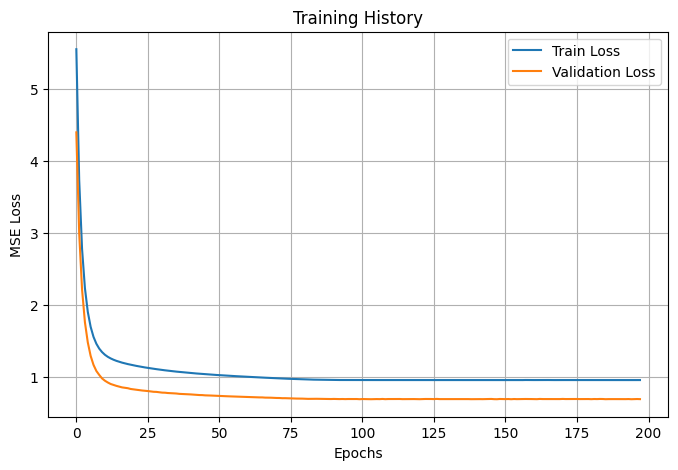

In [24]:
PlotHistory(history)

67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
R²_Training = 0.49632033596496344
MSE_Training = 0.24633387589237418
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R²_Validation = 0.42154732686147617
MSE_Validation = 0.17770214878405624
42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R²_Test 1 = 0.48283239281972284
MSE_Test 1 = 0.23312711955601917
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
R²_Test 2 = 0.414491143774097
MSE_Test 2 = 0.17180290826715916


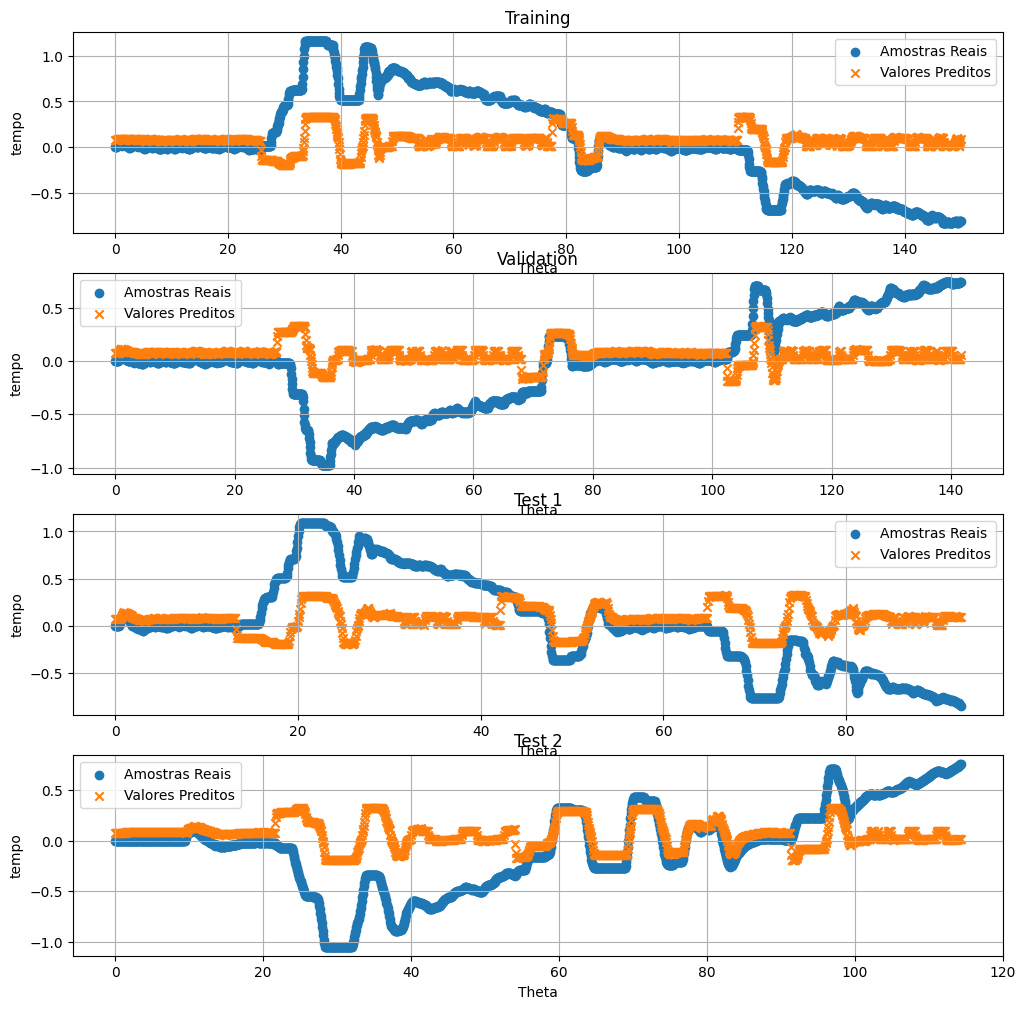

In [25]:
EvalModel(model)